In [1]:
# Install & imports ────────────────────────────────────────────
!pip install -q ultralytics

import os, glob, shutil, random, yaml, cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import Image as IPImage, display
from ultralytics import YOLO
import torch

print(f"Ultralytics ready  |  PyTorch {torch.__version__}")
print(f"GPU available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")

Ultralytics ready  |  PyTorch 2.7.1+cu118
GPU available : True
GPU           : NVIDIA GeForce MX150


In [ ]:
# Mount Drive + verify dataset paths ───────────────────────────

BASE           = r'D:\Academic\L4S1\ComprehensiveGroupProject\FYP'
YOLO_SPLIT     = f'{BASE}/yolo_dataset'          
DATA_YAML      = f'{YOLO_SPLIT}/data.yaml'        
RUNS_DIR       = f'{BASE}/yolo_runs'              
BEST_WEIGHTS   = f'{RUNS_DIR}/roi_detect/weights/best.pt'

os.makedirs(RUNS_DIR, exist_ok=True)

# ── Verify ────────────────────────────────────────────────────────────────
print("── Dataset check ────────────────────────────────────────────────────")
for split in ['train', 'val', 'test']:
    imgs = glob.glob(f'{YOLO_SPLIT}/images/{split}/*.png')
    lbls = glob.glob(f'{YOLO_SPLIT}/labels/{split}/*.txt')
    # only count non-empty label files (images that actually have an ROI)
    labelled = [l for l in lbls if os.path.getsize(l) > 0]
    status = '✅' if len(imgs) == len(lbls) else '❌ COUNT MISMATCH'
    print(f"  {split:<6}: {len(imgs):4d} images  {len(lbls):4d} labels  "
          f"({len(labelled)} with ROI)  {status}")

# Show data.yaml
print()
if os.path.exists(DATA_YAML):
    with open(DATA_YAML) as f:
        print('── data.yaml ─────────────────────────────────────────────────────────')
        print(f.read())
else:
    print(f'❌  data.yaml not found at {DATA_YAML}')
    print('   Run Dataset_Annotation.ipynb Cell 10 first.')

# Count total labelled
all_imgs = glob.glob(f'{YOLO_SPLIT}/images/**/*.png', recursive=True)
print(f"  Total images in split folders : {len(all_imgs)}")

── Dataset check ────────────────────────────────────────────────────
  train : 2129 images  2129 labels  (2129 with ROI)  ✅
  val   :  456 images   456 labels  (456 with ROI)  ✅
  test  :  457 images   457 labels  (457 with ROI)  ✅

── data.yaml ─────────────────────────────────────────────────────────
names:
- roi
nc: 1
path: D:/Academic/L4S1/ComprehensiveGroupProject/FYP/yolo_dataset
test: images/test
train: images/train
val: images/val

  Total images in split folders : 3042


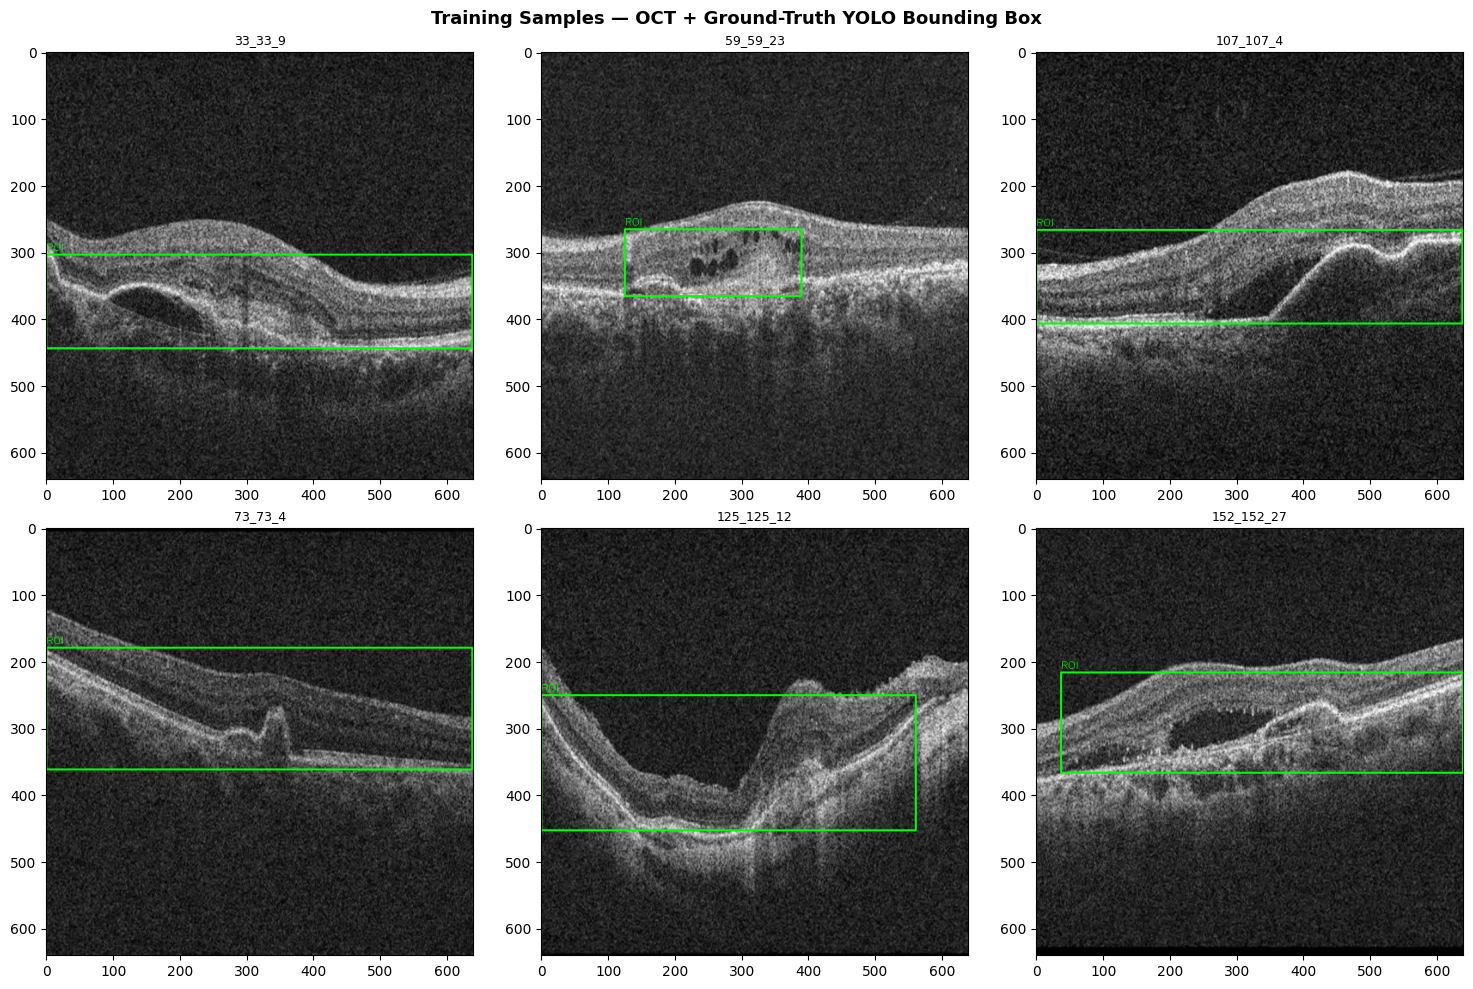

Showing 6 training samples. Saved → /content/train_samples.png


In [3]:
# Visualise training samples ──────────────────────────────────
#
# Shows OCT images with their ground-truth YOLO bounding boxes drawn on.
# Verifies that the annotation pipeline produced correct labels.

def draw_yolo_box(img_bgr, label_path, color=(0,255,0), thickness=2):
    """Draw YOLO normalised bbox on a copy of img_bgr. Returns BGR image."""
    vis = img_bgr.copy()
    h, w = vis.shape[:2]
    if not os.path.exists(label_path) or os.path.getsize(label_path) == 0:
        return vis   # no annotation — return clean image
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5: continue
            _, xc, yc, bw, bh = map(float, parts)
            x1 = int((xc - bw/2) * w);  x2 = int((xc + bw/2) * w)
            y1 = int((yc - bh/2) * h);  y2 = int((yc + bh/2) * h)
            cv2.rectangle(vis, (x1,y1), (x2,y2), color, thickness)
            cv2.putText(vis, 'ROI', (x1, max(y1-6,12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return vis

# Pick up to 6 labelled train images
train_lbls = [f for f in sorted(glob.glob(f'{YOLO_SPLIT}/labels/train/*.txt'))
              if os.path.getsize(f) > 0]
n_show = min(6, len(train_lbls))
sample_lbls = random.sample(train_lbls, n_show)

cols = 3
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = np.array(axes).reshape(-1)
fig.suptitle('Training Samples — OCT + Ground-Truth YOLO Bounding Box',
             fontsize=13, fontweight='bold')

for ax in axes: ax.axis('off')

for i, lbl_path in enumerate(sample_lbls):
    stem     = os.path.splitext(os.path.basename(lbl_path))[0]
    img_path = f'{YOLO_SPLIT}/images/train/{stem}.png'
    img_bgr  = cv2.imread(img_path)
    vis_bgr  = draw_yolo_box(img_bgr, lbl_path)
    axes[i].imshow(cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB))
    axes[i].set_title(stem, fontsize=9)
    axes[i].axis('on')

plt.tight_layout()
plt.savefig(f'{BASE}/train_samples.png', dpi=120)
plt.show()
print(f"Showing {n_show} training samples. Saved → /content/train_samples.png")

In [ ]:
# Transfer learning config ────────────────────────────────────
#

#Count training images to auto-suggest backbone ────────────────────────
n_train = len(glob.glob(f'{YOLO_SPLIT}/images/train/*.png'))
n_val   = len(glob.glob(f'{YOLO_SPLIT}/images/val/*.png'))



#Training hyperparameters ──────────────────────────────────────────────

BACKBONE  = 'yolov8n.pt'        # pre-trained COCO weights (auto-downloaded)

PHASE1 = dict(
    data      = DATA_YAML,
    epochs    = 30,          # short warm-up (head only)
    imgsz     = 640,
    batch     = 8,           
    lr0       = 1e-3,        # initial LR for head layers
    lrf       = 0.1,
    freeze    = 10,          # freeze backbone layers 0-9
    optimizer = 'AdamW',
    cos_lr    = True,
    patience  = 10,          # early stopping patience
    # Augmentation (helps with small datasets) ─────────────
    mosaic    = 0.5,         
    mixup     = 0.1,
    flipud    = 0.0,         
    fliplr    = 0.5,
    hsv_h     = 0.0,         # no hue shift (grayscale OCT)
    hsv_s     = 0.0,
    hsv_v     = 0.3,         # slight brightness variation
    degrees   = 5,           # small rotation
    translate = 0.05,
    scale     = 0.3,
    # Output ─────────────────────────────────────────────────
    project   = RUNS_DIR,
    name      = 'roi_phase1',
    exist_ok  = True,
    device    = 0 if torch.cuda.is_available() else 'cpu',
    verbose   = True,
)

PHASE2 = PHASE1.copy()
PHASE2.update({
    'epochs'  : 50,          # longer fine-tune
    'lr0'     : 1e-4,       
    'lrf'     : 0.01,
    'freeze'  : 0,           # unfreeze entire network
    'mosaic'  : 0.3,         # slightly less aggressive augment
    'patience': 15,
    'name'    : 'roi_detect',
})

print("── Phase 1 config (head warm-up) ─────────────────────────────────────")
for k,v in PHASE1.items(): print(f"  {k:<12}: {v}")
print()
print("── Phase 2 config (full fine-tune) ──────────────────────────────────")
for k,v in PHASE2.items(): print(f"  {k:<12}: {v}")

── Phase 1 config (head warm-up) ─────────────────────────────────────
  data        : D:\Academic\L4S1\ComprehensiveGroupProject\FYP/yolo_dataset/data.yaml
  epochs      : 30
  imgsz       : 640
  batch       : 8
  lr0         : 0.001
  lrf         : 0.1
  freeze      : 10
  optimizer   : AdamW
  cos_lr      : True
  patience    : 10
  mosaic      : 0.5
  mixup       : 0.1
  flipud      : 0.0
  fliplr      : 0.5
  hsv_h       : 0.0
  hsv_s       : 0.0
  hsv_v       : 0.3
  degrees     : 5
  translate   : 0.05
  scale       : 0.3
  project     : D:\Academic\L4S1\ComprehensiveGroupProject\FYP/yolo_runs
  name        : roi_phase1
  exist_ok    : True
  device      : 0
  verbose     : True

── Phase 2 config (full fine-tune) ──────────────────────────────────
  data        : D:\Academic\L4S1\ComprehensiveGroupProject\FYP/yolo_dataset/data.yaml
  epochs      : 50
  imgsz       : 640
  batch       : 8
  lr0         : 0.0001
  lrf         : 0.01
  freeze      : 0
  optimizer   : AdamW
  cos_

In [ ]:
# Phase 1 — warm up head only (backbone frozen) ───────────────
#
# The pre-trained COCO backbone is frozen (layers 0-9 not updated).
# Only the detection head learns to output 'ROI' class bboxes.
# This prevents destroying COCO features early in training.

print(f"Loading backbone: {BACKBONE}  (downloads ~6 MB if not cached)")
model_p1 = YOLO(BACKBONE)

print(f"\n── Phase 1 · {PHASE1['epochs']} epochs, freeze={PHASE1['freeze']} ──")
results_p1 = model_p1.train(**PHASE1)

print("── Phase 1 complete ─────────────────────────────────────────────────")
p1_best = f"{RUNS_DIR}/roi_phase1/weights/best.pt"
print(f"  Best weights → {p1_best}")

# Safe print — handles both float and 'N/A' string
def fmt(val):
    return f"{val:.4f}" if isinstance(val, float) else str(val)

print(f"  box_loss : {fmt(results_p1.results_dict.get('train/box_loss', 'N/A'))}")
print(f"  mAP50    : {fmt(results_p1.results_dict.get('metrics/mAP50(B)', 'N/A'))}")

# Print all available keys so you know exact names for future reference
print("\n── All available result keys ─────────────────────────────────────────")
for k, v in results_p1.results_dict.items():
    print(f"  {k:<35}: {fmt(v)}")

Loading backbone: yolov8n.pt  (downloads ~6 MB if not cached)

── Phase 1 · 30 epochs, freeze=10 ──
Ultralytics 8.4.45  Python-3.10.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce MX150, 2048MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\Academic\L4S1\ComprehensiveGroupProject\FYP/yolo_dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937,

In [ ]:
# Phase 2 — fine-tune full network (low LR) ───────────────────

p1_best = f"{RUNS_DIR}/roi_phase1/weights/best.pt"

print(f"Loading Phase 1 weights: {p1_best}")
model_p2 = YOLO(p1_best)

print(f"\n── Phase 2 · {PHASE2['epochs']} epochs, freeze=0 (full fine-tune) ──")
results_p2 = model_p2.train(**PHASE2)

# Safe formatter
def fmt(val):
    return f"{val:.4f}" if isinstance(val, float) else str(val)

print("\n── Phase 2 complete ─────────────────────────────────────────────────")
print(f"  Best weights → {BEST_WEIGHTS}")
print(f"  box_loss     : {fmt(results_p2.results_dict.get('train/box_loss',       'N/A'))}")
print(f"  mAP50        : {fmt(results_p2.results_dict.get('metrics/mAP50(B)',     'N/A'))}")
print(f"  mAP50-95     : {fmt(results_p2.results_dict.get('metrics/mAP50-95(B)', 'N/A'))}")

print("\n── All available result keys ─────────────────────────────────────────")
for k, v in results_p2.results_dict.items():
    print(f"  {k:<35}: {fmt(v)}")

Loading Phase 1 weights: D:\Academic\L4S1\ComprehensiveGroupProject\FYP/yolo_runs/roi_phase1/weights/best.pt

── Phase 2 · 50 epochs, freeze=0 (full fine-tune) ──
Ultralytics 8.4.45  Python-3.10.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce MX150, 2048MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\Academic\L4S1\ComprehensiveGroupProject\FYP/yolo_dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_d

── Validation metrics ───────────────────────────────────────────────
Ultralytics 8.4.45  Python-3.10.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce MX150, 2048MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 30.416.1 ms, read: 13.62.4 MB/s, size: 807.6 KB)
val: Scanning D:\Academic\L4S1\ComprehensiveGroupProject\FYP\yolo_dataset\labels\val.cache... 456 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 456/456  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 2.4it/s 11.9s0.4s
                   all        456        456      0.926      0.906      0.972      0.719
Speed: 2.5ms preprocess, 18.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to C:\Users\asang\runs\detect\val-2
  Precision  : 0.926399867111263
  Recall     : 0.9057017543859649
  mAP@0.50   : 0.9722887569056822
  mAP@.5:.95 : 0.7186737206602658

── Test metrics ────────

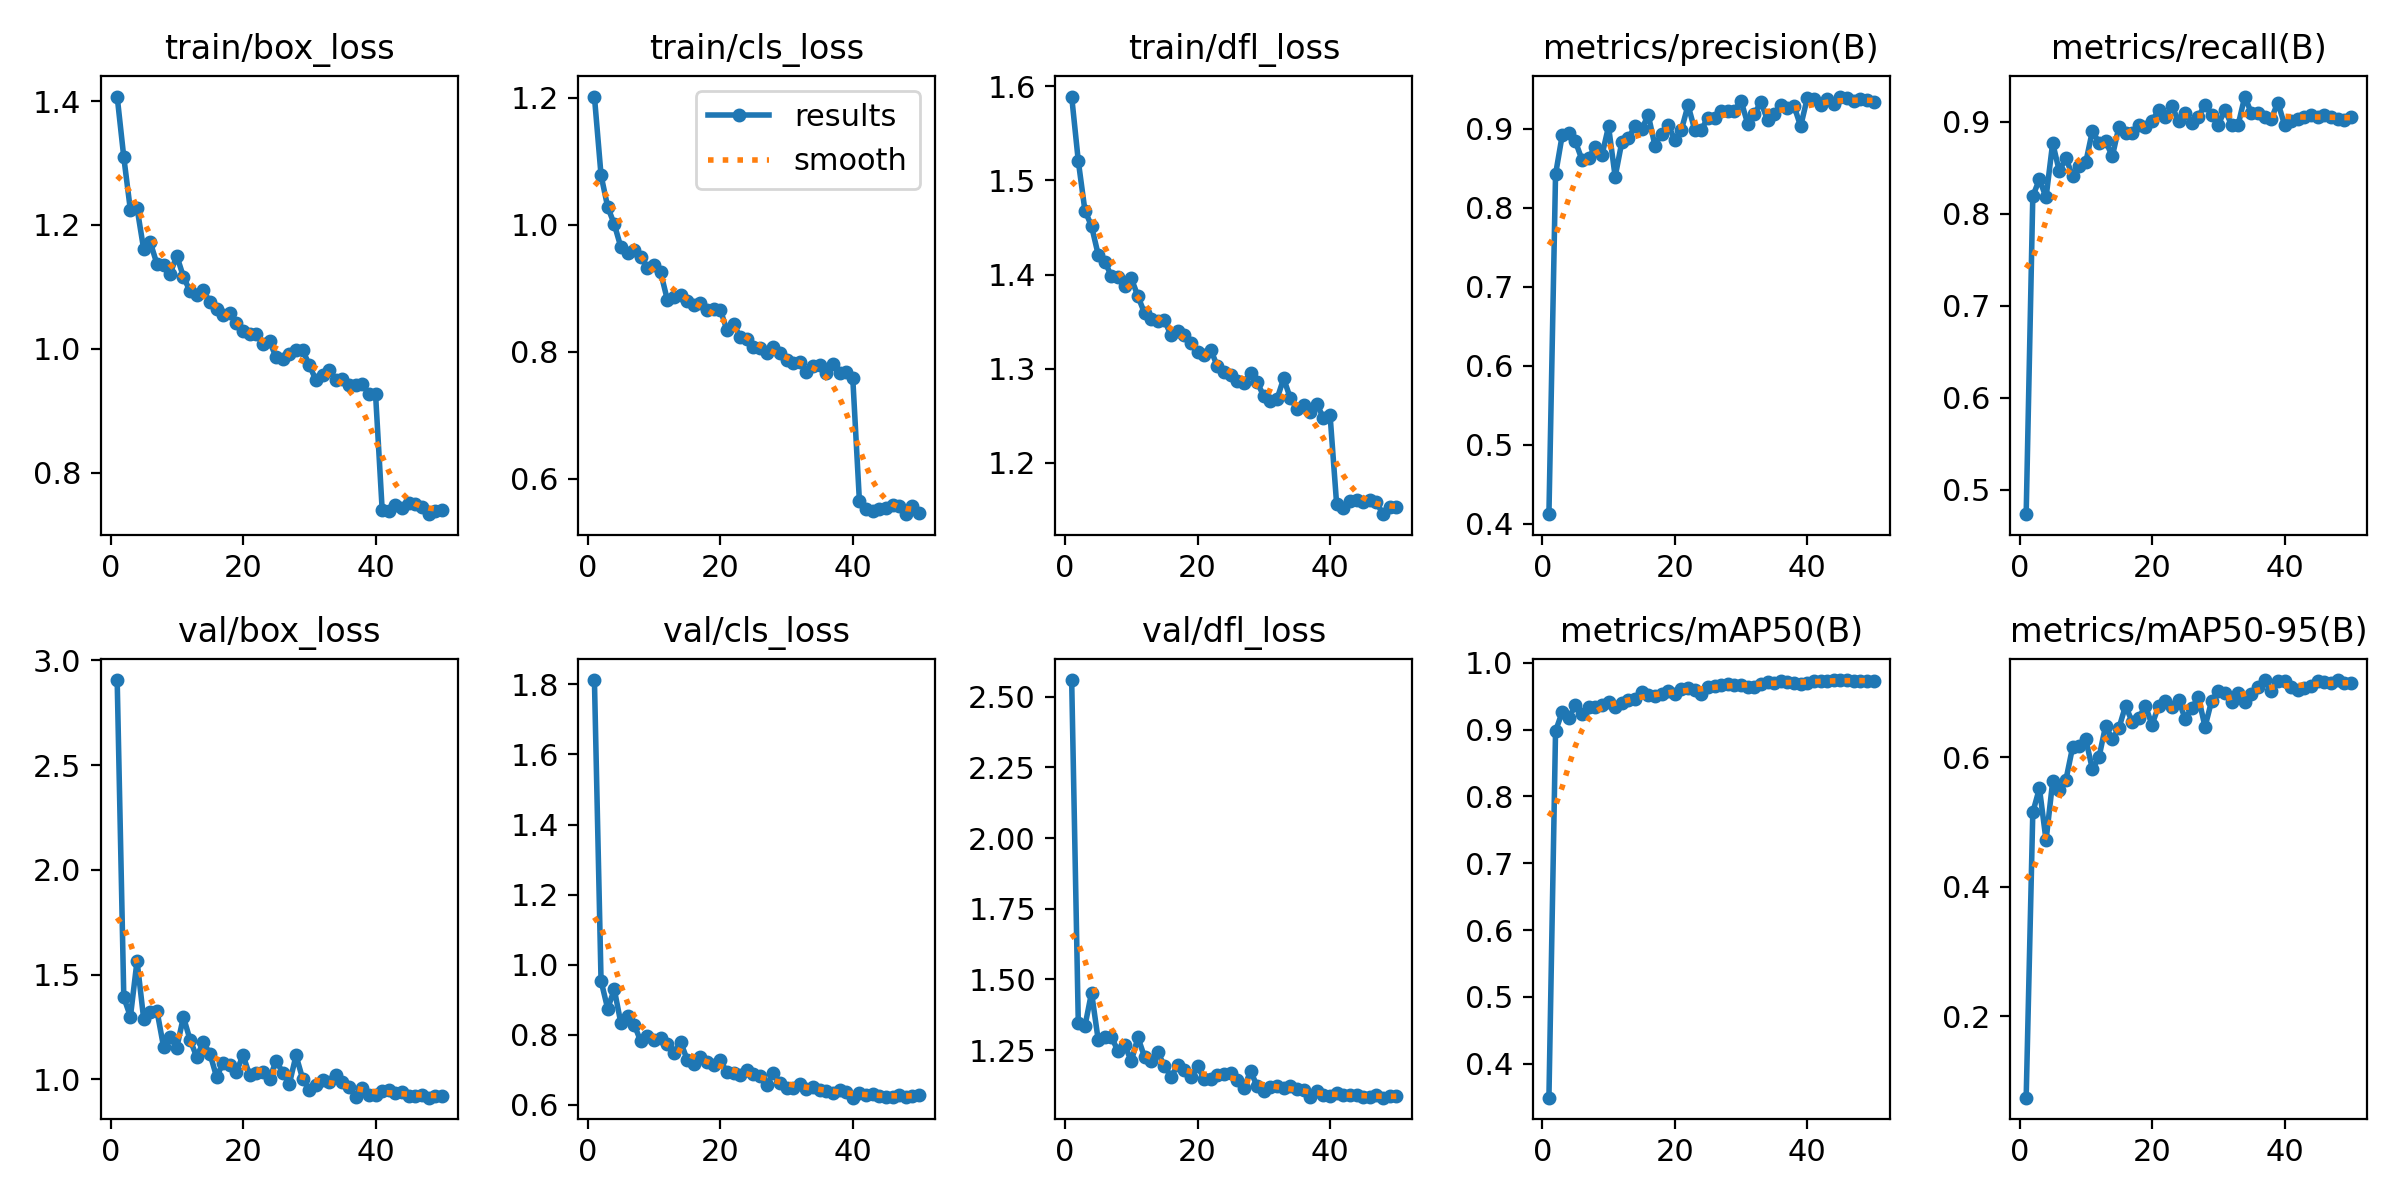

Curves → D:\Academic\L4S1\ComprehensiveGroupProject\FYP/yolo_runs/roi_detect/results.png


In [ ]:
#  Evaluate on val + test splits ────────────────────────────────

best_model = YOLO(BEST_WEIGHTS)

# ── Validation split ──────────────────────────────────────────────────────
print("── Validation metrics ───────────────────────────────────────────────")
val_metrics = best_model.val(
    data    = DATA_YAML,
    split   = 'val',
    imgsz   = 640,
    device  = 0 if torch.cuda.is_available() else 'cpu',
    verbose = False,
)
print(f"  Precision  : {val_metrics.results_dict.get('metrics/precision(B)', 0)}")
print(f"  Recall     : {val_metrics.results_dict.get('metrics/recall(B)',    0)}")
print(f"  mAP@0.50   : {val_metrics.results_dict.get('metrics/mAP50(B)',     0)}")
print(f"  mAP@.5:.95 : {val_metrics.results_dict.get('metrics/mAP50-95(B)', 0)}")

# ── Test split ────────────────────────────────────────────────────────────
print()
print("── Test metrics ─────────────────────────────────────────────────────")
test_metrics = best_model.val(
    data    = DATA_YAML,
    split   = 'test',
    imgsz   = 640,
    device  = 0 if torch.cuda.is_available() else 'cpu',
    verbose = False,
)
print(f"  Precision  : {test_metrics.results_dict.get('metrics/precision(B)', 0)}")
print(f"  Recall     : {test_metrics.results_dict.get('metrics/recall(B)',    0)}")
print(f"  mAP@0.50   : {test_metrics.results_dict.get('metrics/mAP50(B)',     0)}")
print(f"  mAP@.5:.95 : {test_metrics.results_dict.get('metrics/mAP50-95(B)', 0)}")

# ── Plot training curves saved by YOLO ───────────────────────────────────
results_png = f'{RUNS_DIR}/roi_detect/results.png'
if os.path.exists(results_png):
    display(IPImage(filename=results_png))
    print(f"Curves → {results_png}")

# Confusion matrix
conf_png = f'{RUNS_DIR}/roi_detect/val/confusion_matrix.png'
if os.path.exists(conf_png):
    display(IPImage(filename=conf_png))
    print(f"Confusion matrix → {conf_png}")

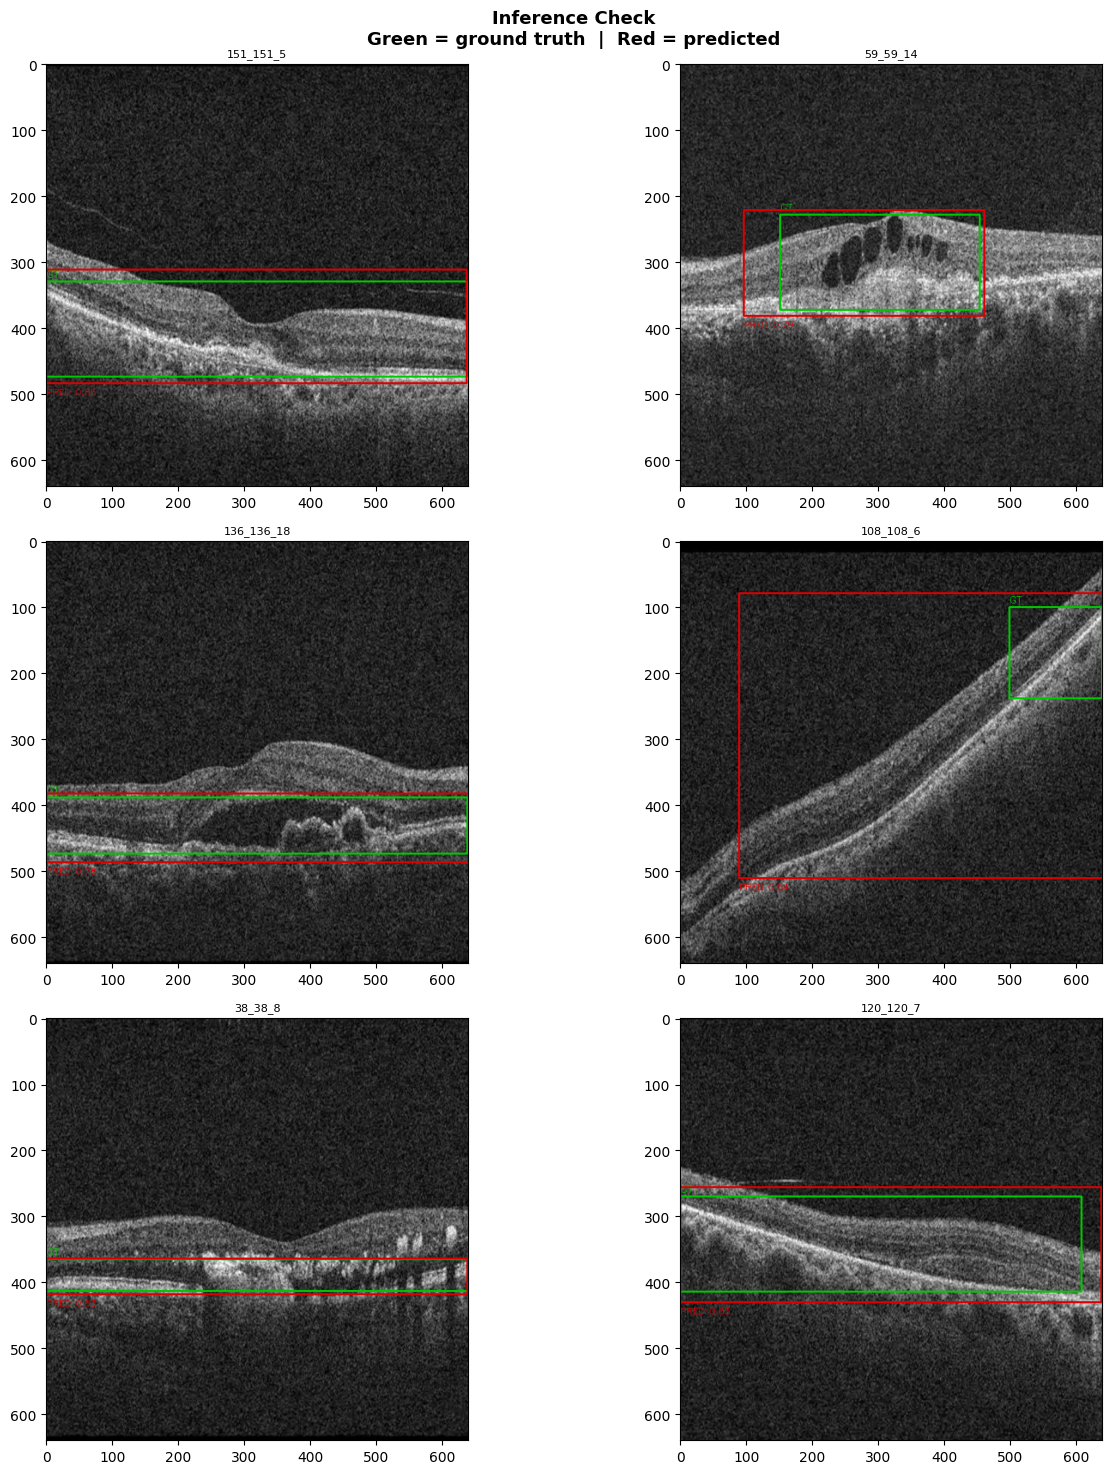

Saved → /content/inference_check.png


In [ ]:
# Visual inference check ──────────────────────────────────────
#
# Runs the trained model on a mix of val + test images and shows
# predicted boxes vs ground-truth boxes side by side.
best_model = YOLO(BEST_WEIGHTS)
CONF_THRESH = 0.25    # detection confidence threshold — lower = more detections
IOU_THRESH  = 0.45    # NMS IoU threshold
N_SHOW      = 6       # how many images to display

# Collect images from val + test
check_imgs = []
for split in ['val', 'test']:
    check_imgs += glob.glob(f'{YOLO_SPLIT}/images/{split}/*.png')
random.shuffle(check_imgs)
check_imgs = check_imgs[:N_SHOW]

cols = 2
rows = (len(check_imgs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 5*rows))
axes = np.array(axes).reshape(-1)
fig.suptitle('Inference Check\n'
             'Green = ground truth  |  Red = predicted',
             fontsize=13, fontweight='bold')
for ax in axes: ax.axis('off')

for i, img_path in enumerate(check_imgs):
    img_bgr = cv2.imread(img_path)
    h, w    = img_bgr.shape[:2]
    vis     = img_bgr.copy()

    # Ground-truth box (green)
    stem    = os.path.splitext(os.path.basename(img_path))[0]
    # find the label in whichever split folder it's in
    lbl_candidates = glob.glob(f'{YOLO_SPLIT}/labels/**/{stem}.txt', recursive=True)
    if lbl_candidates and os.path.getsize(lbl_candidates[0]) > 0:
        with open(lbl_candidates[0]) as f:
            for line in f:
                _, xc, yc, bw, bh = map(float, line.strip().split())
                x1 = int((xc-bw/2)*w); x2 = int((xc+bw/2)*w)
                y1 = int((yc-bh/2)*h); y2 = int((yc+bh/2)*h)
                cv2.rectangle(vis, (x1,y1), (x2,y2), (0,200,0), 2)
                cv2.putText(vis, 'GT', (x1, max(y1-6,12)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,200,0), 1)

    # Predicted box (red)
    preds = best_model.predict(
        img_path, conf=CONF_THRESH, iou=IOU_THRESH, verbose=False)[0]
    for box in preds.boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0].cpu().numpy())
        conf = float(box.conf[0])
        cv2.rectangle(vis, (x1,y1), (x2,y2), (0,0,220), 2)
        cv2.putText(vis, f'PRED {conf:.2f}', (x1, min(y2+18, h-2)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,0,220), 1)

    axes[i].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[i].set_title(stem, fontsize=8)
    axes[i].axis('on')

plt.tight_layout()
plt.savefig(f'{BASE}/inference_check.png', dpi=120)
plt.show()
print("Saved → /content/inference_check.png")